In [23]:
# Análisis Exploratorio de las compras ventas en Amazon

Este notebook explora compras em Amazon (e-commerce), con el objetivo de responder:

- ¿Qué categorías generan más ventas?
- ¿Qué productos tienen mejor valoración?
- ¿Existe relación entre precio y rating?
- ¿Qué productos concentran más reseñas?
- ¿Hay estacionalidad en las compras?
- ¿Qué marcas dominan cada categoría?

In [24]:
# ----------------------------------------------------------
# Librerías y carga de datos
# ----------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Estilo de gráficos
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

# Cargar datos
df = pd.read_csv("../data/amazon.csv")

# Primer vistazo al dataset
df.head()

,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Cha...,Computers&Accessories|Accessories&Peripherals|...,₹399,"₹1,099",64%,4.2,"24,269",High Compatibility : Compatible With iPhone 12...,"AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBB...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jasp...","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1K...","Satisfied,Charging is really fast,Value for mo...",Looks durable Charging is fine tooNo complains...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Wayona-Braided-WN3LG1-Sy...
1,B098NS6PVG,Ambrane Unbreakable 60W / 3A Fast Charging 1.5...,Computers&Accessories|Accessories&Peripherals|...,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBX...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Plac...","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RY...","A Good Braided Cable for Your Type C Device,Go...",I ordered this cable to connect my phone to An...,https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Ambrane-Unbreakable-Char...
2,B096MSW6CT,Sounce Fast Phone Charging Cable & Data Sync U...,Computers&Accessories|Accessories&Peripherals|...,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safet...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQ...","Kunal,Himanshu,viswanath,sai niharka,saqib mal...","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R2...","Good speed for earlier versions,Good Product,W...","Not quite durable and sturdy,https://m.media-a...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Sounce-iPhone-Charging-C...
3,B08HDJ86NZ,boAt Deuce USB 300 2 in 1 Type-C & Micro USB S...,Computers&Accessories|Accessories&Peripherals|...,₹329,₹699,53%,4.2,"94,363",The boAt Deuce USB 300 2 in 1 cable is compati...,"AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5S...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh ...","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1...","Good product,Good one,Nice,Really nice product...","Good product,long wire,Charges good,Nice,I bou...",https://m.media-amazon.com/images/I/41V5FtEWPk...,https://www.amazon.in/Deuce-300-Resistant-Tang...
4,B08CF3B7N1,Portronics Konnect L 1.2M Fast Charging 3A 8 P...,Computers&Accessories|Accessories&Peripherals|...,₹154,₹399,61%,4.2,"16,905",[CHARGE & SYNC FUNCTION]- This cable comes wit...,"AE3Q6KSUK5P75D5HFYHCRAOLODSA,AFUGIFH5ZAFXRDSZH...","rahuls6099,Swasat Borah,Ajay Wadke,Pranali,RVK...","R1BP4L2HH9TFUP,R16PVJEXKV6QZS,R2UPDB81N66T4P,R...","As good as original,Decent,Good one for second...","Bought this instead of original apple, does th...",https://m.media-amazon.com/images/W/WEBP_40237...,https://www.amazon.in/Portronics-Konnect-POR-1...


## Descripción de columnas

- `product_id`: ID del producto
- `product_name`: Nombre del producto
- `category`: Categoría
- `discounted_price`: Precio con descuento
- `actual_price`: Precio original antes del descuento
- `discount_percentage`: Porcentaje de descuento
- `rating`: Calificacion del producto
- `rating_count`: Cantidad de valoraciones
- `about_product`: Detalles del producto
- `user_id`: ID usuario de reseña
- `user_name`: Nombre suario de reseña
- `review_id`: ID de la reseña
- `review_title`: Título de la reseña
- `review_content`: Contenido de la reseña
- `img_link`: Imagen del producto
- `product_link`: URL del producto

category_level_1
Electronics              526
Computers&Accessories    453
Home&Kitchen             448
OfficeProducts            31
MusicalInstruments         2
HomeImprovement            2
Toys&Games                 1
Car&Motorbike              1
Health&PersonalCare        1
Name: count, dtype: int64


Text(0, 0.5, 'Categoría nivel 1')

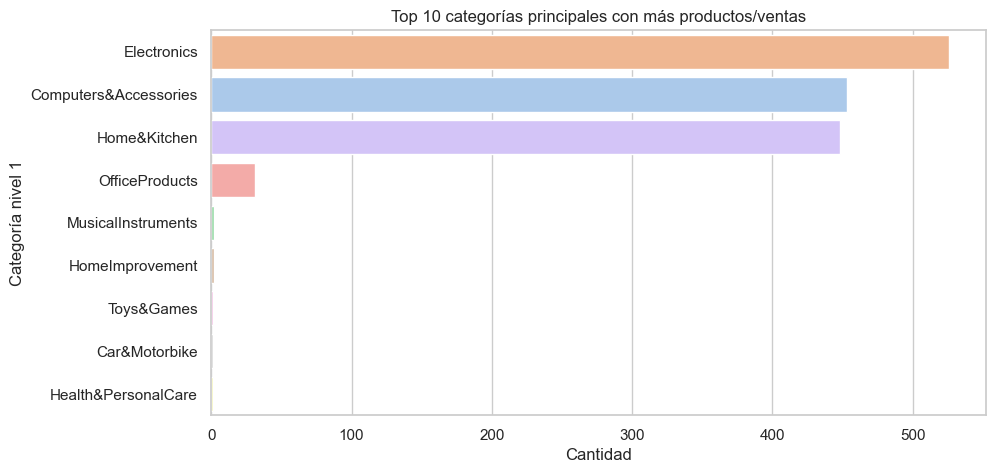

In [25]:
# ----------------------------------------------------------
# Limpieza y tratamiento de datos
# ----------------------------------------------------------

# Rellenamos columnas importantes
df['rating_count'] = df['rating_count'].fillna(0)

# Quitamos caracteres ₹
df['discounted_price'] = (df['discounted_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False))
df['actual_price'] = (df['actual_price'].str.replace('₹', '', regex=False).str.replace(',', '', regex=False))

# Quitamos caracteres %
df['discount_percentage'] = (df['discount_percentage'].str.replace('%', '', regex=False))

# Convertir las columnas de tipo
cols = ['rating','rating_count','discounted_price', 'actual_price', 'discount_percentage']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

# ----------------------------------------------------------
# Análisis exploratorio
# ----------------------------------------------------------
# 1 Categorías con más ventas
# Calcular número máximo de niveles en 'category' (raw string para la barra)
max_levels = df['category'].str.count(r'\|').max() + 1
cols = [f'category_level_{i+1}' for i in range(max_levels)]

# Dividir categorías y asignar a nuevas columnas
df[cols] = df['category'].str.split('|', expand=True)

# Contar ventas por categoría nivel 1
ventas_por_categoria = df['category_level_1'].value_counts()
print(ventas_por_categoria)

# Seleccionar las 10 categorías principales para graficar
top_categories = ventas_por_categoria.head(10).index

# Graficar top 10 categorías nivel 1
sns.countplot(
    data=df[df['category_level_1'].isin(top_categories)],
    y='category_level_1',
    order=top_categories,
    hue='category_level_1',
    palette='pastel',
    legend=False
)

plt.title('Top 10 categorías principales con más productos/ventas')
plt.xlabel('Cantidad')
plt.ylabel('Categoría nivel 1')

# Mostramos gráfico
# plt.show()

**Conclusión:**  
La categoría más vendida es Electrónica, que representa un 35,9% de las ventas, seguida de cerca por Ordenadores y Accesorios, con aproximadamente un 30% de las ventas totales.

In [26]:
# 2 Productos con mejor valoración
# Crear un indicador combinado: “score ponderado”  Weighted Rating de IMDB: score = (v/v+m) . R + (m/v+m) . C
C = df['rating'].mean()
m = 50  # por ejemplo, mínimo 50 reseñas para ponderar

df['weighted_score'] = (df['rating_count']/(df['rating_count']+m) * df['rating']) + (m/(df['rating_count']+m) * C)

# Ordenamos por weighted_score agruoando por 'product_id', 'product_name', 'category'
top_products_unique = df.groupby(['product_id', 'product_name', 'category']).agg({
    'weighted_score': 'mean',
    'rating': 'mean',
    'rating_count': 'sum'
}).reset_index()

top_products_unique = top_products_unique.sort_values(by='weighted_score', ascending=False).head(10)
print(top_products_unique)

      product_id                                       product_name  \
1262  B0B9BXKBC7  WeCool S5 Long Selfie Stick, with Large Reinfo...   
877   B09C6HXFC1  Duracell USB Lightning Apple Certified (Mfi) B...   
1246  B0B8CHJLWJ  Kyosei Advanced Tempered Glass Compatible with...   
547   B084N18QZY  Belkin USB C to USB-C Fast Charging Type C Cab...   
1170  B0B3G5XZN5  InstaCuppa Portable Blender for Smoothie, Milk...   
1055  B09TT6BFDX  Cotbolt Silicone Protective Case Cover for LG ...   
545   B084MZYBTV  Belkin USB C to USB-C Fast Charging Type C Cab...   
1286  B0BCVJ3PVP  SupCares Laptop Stand 7 Height Adjustable, Alu...   
1313  B0BJ966M5K  Aquadpure Copper + Mineral RO+UV+UF 10 to 12 L...   
932   B09JN37WBX  Lint Remover Woolen Clothes Lint Extractor Bat...   

                                               category  weighted_score  \
1262  Electronics|Mobiles&Accessories|MobileAccessor...        4.514675   
877   Computers&Accessories|Accessories&Peripherals|...        4.476

**Conclusión:**  
Los productos mejor valorados en la aplicación son principalmente accesorios electrónicos, como trípodes para móviles y cables de carga para Apple, que combinan buena calificación con un alto número de reseñas.

Correlación precio original vs rating: 0.12164167545801735
Correlación precio con descuento vs rating: 0.12033741712288534


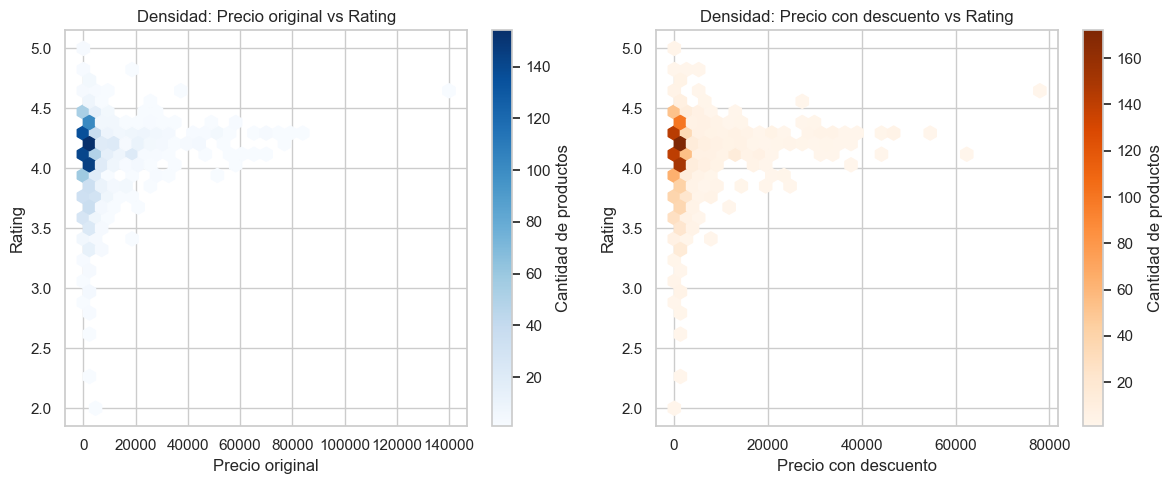

In [31]:
# 3 Relación entre precio y rating
# Correlación entre precio original y rating
corr_actual = df['actual_price'].corr(df['rating'])
# Correlación entre precio con descuento y rating
corr_discounted = df['discounted_price'].corr(df['rating'])

print("Correlación precio original vs rating:", corr_actual)
print("Correlación precio con descuento vs rating:", corr_discounted)

# ----------------------------------------------------------
# Hexbin plot para densidad de puntos
# ----------------------------------------------------------
plt.figure(figsize=(12,5))

# Precio original vs rating
plt.subplot(1,2,1)
plt.hexbin(df['actual_price'], df['rating'], gridsize=30, cmap='Blues', mincnt=1)
plt.colorbar(label='Cantidad de productos')
plt.title('Densidad: Precio original vs Rating')
plt.xlabel('Precio original')
plt.ylabel('Rating')

# Precio con descuento vs rating
plt.subplot(1,2,2)
plt.hexbin(df['discounted_price'], df['rating'], gridsize=30, cmap='Oranges', mincnt=1)
plt.colorbar(label='Cantidad de productos')
plt.title('Densidad: Precio con descuento vs Rating')
plt.xlabel('Precio con descuento')
plt.ylabel('Rating')

plt.tight_layout()
plt.show()

In [ ]:
**Conclusión:**  
La valoración de los productos en Amazon no depende del precio. La mayoría de los productos tienen ratings altos (4–5 estrellas) tanto si son económicos como si son caros, por lo que no se observa una relación significativa entre precio y rating.

In [36]:
# 4 Productos con más reseñas
# Agrupar por producto y categoría, sumando todas las reseñas
reseñas_por_producto = df.groupby(['product_name', 'category_level_1'])['rating_count'].sum().reset_index()

# Ordenar de mayor a menor y tomar top 10
top_reseñados = reseñas_por_producto.sort_values(by='rating_count', ascending=False).head(10)

# Mostrar tabla resumida
print("Top 10 productos que concentran más reseñas (con categoría):")
display(top_reseñados)


Top 10 productos que concentran más reseñas (con categoría):


,product_name,category_level_1,rating_count
325,Duracell USB Lightning Apple Certified (Mfi) B...,Computers&Accessories,2445.0
1237,Zoul USB C 60W Fast Charging 3A 6ft/2M Long Ty...,Computers&Accessories,1948.0
121,Ambrane 2 in 1 Type-C & Micro USB Cable with 6...,Computers&Accessories,1806.0
1179,Wecool Unbreakable 3 in 1 Charging Cable with ...,Computers&Accessories,1312.0
1022,"Sounce 65W OnePlus Dash Warp Charge Cable, 6.5...",Computers&Accessories,1151.0
947,SWAPKART Fast Charging Cable and Data Sync USB...,Computers&Accessories,1072.0
363,Eureka Forbes car Vac 100 Watts Powerful Sucti...,Home&Kitchen,992.0
365,Eveready Red 1012 AAA Batteries - Pack of 10,Electronics,989.0
807,Pigeon 1.5 litre Hot Kettle and Stainless Stee...,Home&Kitchen,976.0
1239,Zoul USB Type C Fast Charging 3A Nylon Braided...,Computers&Accessories,974.0


In [ ]:
**Conclusión:**
Los productos que concentran más reseñas son principalmente trípodes para móviles, cables de carga y accesorios de Apple, de las categorías Electrónica y Computers & Accessories. Esto indica que son populares y generan mucho feedback, siendo un buen indicador de interés del consumidor para decisiones de marketing y promoción de productos estrella.